In [1]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
L = 200
f_cut = 3/L

fs = 1
N = 4
btype = 'highpass'

b, a = signal.butter(N=N, Wn=f_cut, btype=btype, fs=fs)

w, h = signal.freqz(b, a, fs=fs)

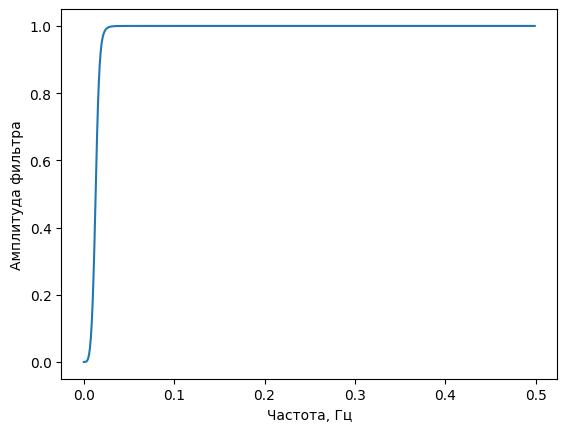

In [10]:
# рисунок 17 в дипломе

plt.plot(w, np.abs(h))
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда фильтра')
#plt.savefig('highpass_filter_freqResp.jpg')
plt.show()

In [3]:
import generate_areas as ga
from fringe_class import Fringe, FringeList
%load_ext autoreload
%autoreload 2

## Illustration for high-pass filter, filtering off the lowest 3 frequencies

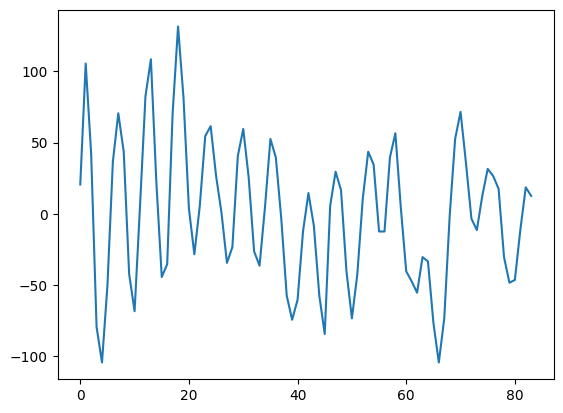

In [22]:
img_path = 'drop-211025-2/drop-0110.jpg'

sel = ga.SelectArea(img_path=img_path)
sel.select_roi()

fringe_tm = sel.extract()
fringe_tm.plot()

json_path = 'drop-0110.json'
fringe_tm.to_json(json_path)

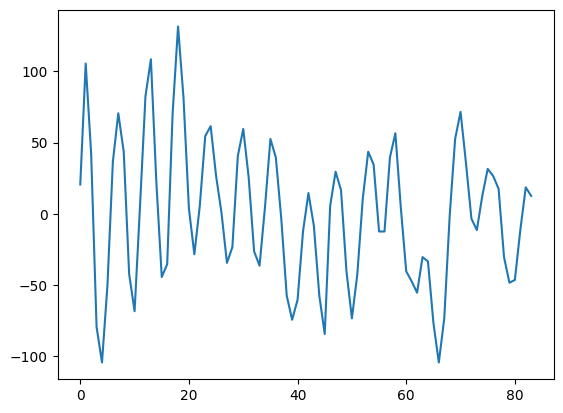

In [23]:
fringe = Fringe()
fringe.sig_from_json(json_path)
fringe.plot()

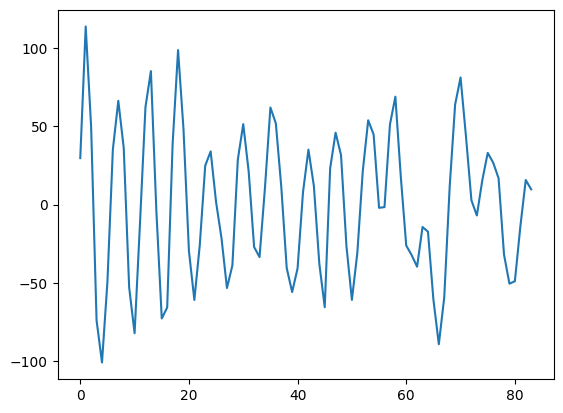

In [24]:
fringe_h = fringe.filter_low_frq(nl=3, inplace=False)
fringe_h.plot()

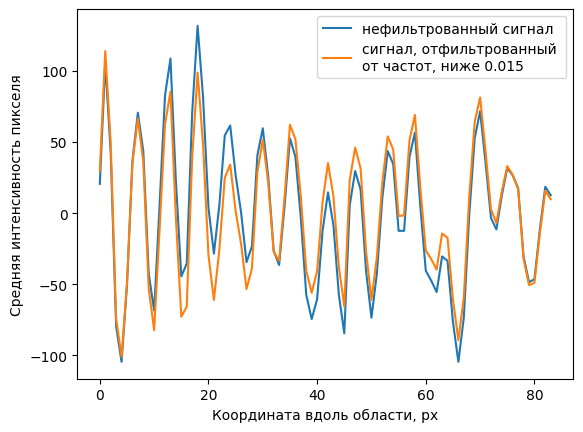

In [25]:
x = np.arange(fringe.sig_len)

plt.figure()

plt.plot(x, fringe.sig)
plt.plot(x, fringe_h.sig)
plt.xlabel("Координата вдоль области, px")
plt.ylabel("Средняя интенсивность пикселя")
plt.legend(labels=["нефильтрованный сигнал",f'сигнал, отфильтрованный \nот частот, ниже {f_cut}'], loc="upper right")

plt.savefig("filter_low_frq_demo.jpg")
plt.show()

## Illustration for Butterwort bandpass filter creation from spectral dencity distribution

In [4]:
import sig_analize as sa

In [5]:
def my_butter(sig, fs=1, N=4, rel_h = 0.7, nperseg = 250):
    # fs -sampling frequency

    fxx, Pxx_den = signal.welch(np.real(sig), fs = fs, nperseg=nperseg)
    fxx_len = len(fxx)
    
    peak = np.argmax(Pxx_den)
    width = signal.peak_widths(Pxx_den,[peak], rel_height = rel_h)
    
    Wn = [width[2]*fs/2/(fxx_len-1), width[3]*fs/2/(fxx_len-1)]
    
    btype = 'bandpass'

    b, a  = signal.butter(N, Wn, btype, fs = fs)
    w, h = signal.freqz(b, a, fs=fs)

    plt.figure()
    plt.plot(fxx, Pxx_den/np.max(Pxx_den))
    plt.hlines(width[1]/np.max(Pxx_den), *Wn, color= 'C2')
    plt.plot(w, np.abs(h))
    
    plt.xlabel("Частота, Гц")
    plt.ylabel("Нормированная амплитуда")
    plt.legend(["спектральная плотность \nмощности сигнала",
                "ширина пика на уровне 0.25",
                "амплитудная \nхарактеристика \nфильтра"], loc="upper right")

    plt.savefig('bandpass_filter_creation.jpg')
    plt.show()

    return b, a

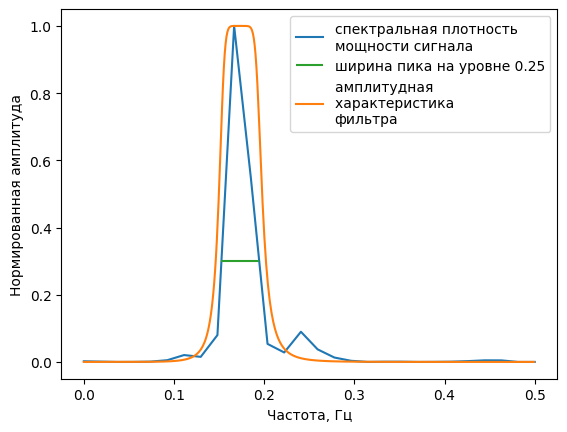

(array([ 0.00021781,  0.        , -0.00087125,  0.        ,  0.00130688,
         0.        , -0.00087125,  0.        ,  0.00021781]),
 array([  1.        ,  -3.40931065,   7.68229284, -11.01133924,
         12.01331211,  -9.26724282,   5.44112141,  -2.03043643,
          0.50133366]))

In [52]:
my_butter(sig=fringe_h.sig, nperseg=fringe_h.sig_len)

## Compare signals with different levels of filtration

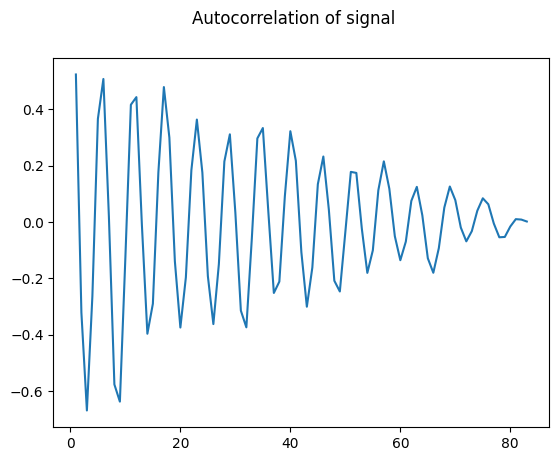

14


In [26]:
peak_count = fringe_h.count_peaks_of_autocorr(show=True)
print(peak_count)

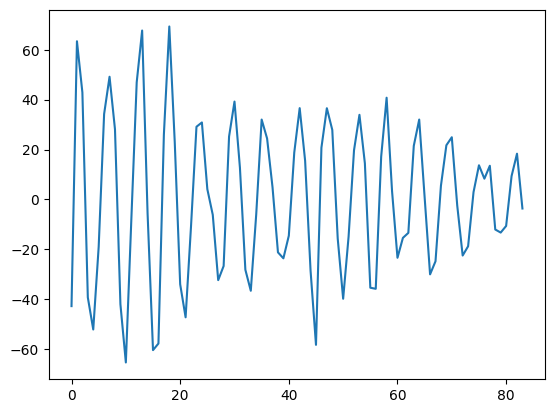

In [27]:
fringe_h8 = fringe_h.filter_low_frq(nl=peak_count-1,inplace=False)
fringe_h8.plot()

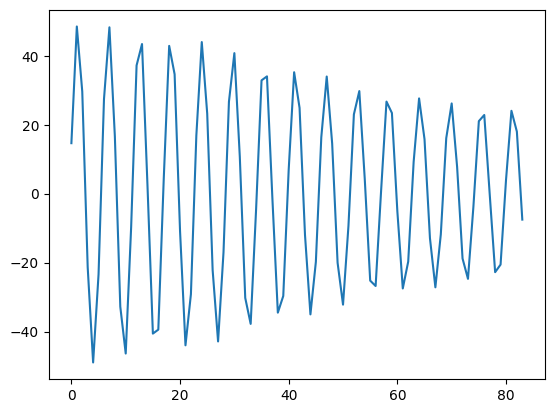

In [28]:
fringe_Wn = fringe_h8.filter_notch_Wn(border=4, updateWn=True, rel_h=0.5, nperseg_c=1, inplace=False)
fringe_Wn.plot()

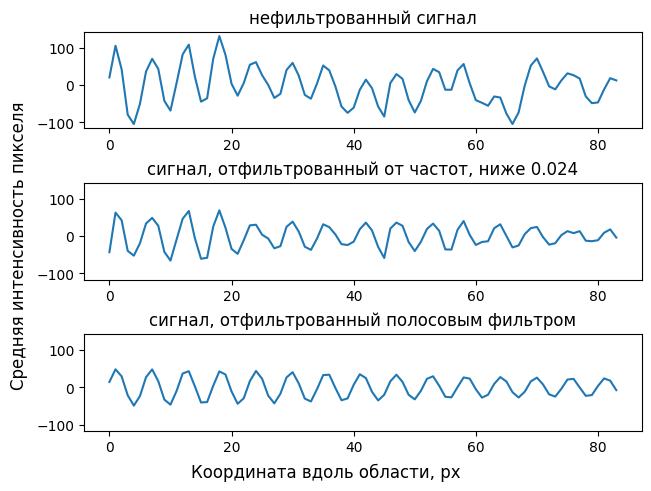

In [29]:
x = np.arange(fringe.sig_len)

fig, ax = plt.subplots(3, 1, layout="constrained", sharey=True)

ax[0].plot(x, fringe.sig)
ax[0].set_title("нефильтрованный сигнал")
ax[1].plot(x, fringe_h8.sig)
ax[1].set_title(f'сигнал, отфильтрованный от частот, ниже {f_cut/5*8}')
ax[2].plot(x, fringe_Wn.sig)
ax[2].set_title(f'сигнал, отфильтрованный полосовым фильтром')

fig.supxlabel("Координата вдоль области, px")
fig.supylabel("Средняя интенсивность пикселя")


plt.savefig("filter_signal_demo.jpg")
plt.show()

In [30]:
f, p_den = signal.welch(fringe.sig, fs = fs, nperseg=fringe.sig_len)
fh, p_denh = signal.welch(fringe_h8.sig, fs = fs, nperseg=fringe_h8.sig_len)
fw, p_denw = signal.welch(fringe_Wn.sig, fs = fs, nperseg=fringe_Wn.sig_len)

In [31]:
anal_y = signal.hilbert(np.real(fringe.sig))
ph = np.unwrap(np.angle(anal_y))

anal_y = signal.hilbert(np.real(fringe_h8.sig))
ph_h = np.unwrap(np.angle(anal_y))

anal_y = signal.hilbert(np.real(fringe_Wn.sig))
ph_w = np.unwrap(np.angle(anal_y))

In [78]:
import matplotlib.gridspec as gridspec

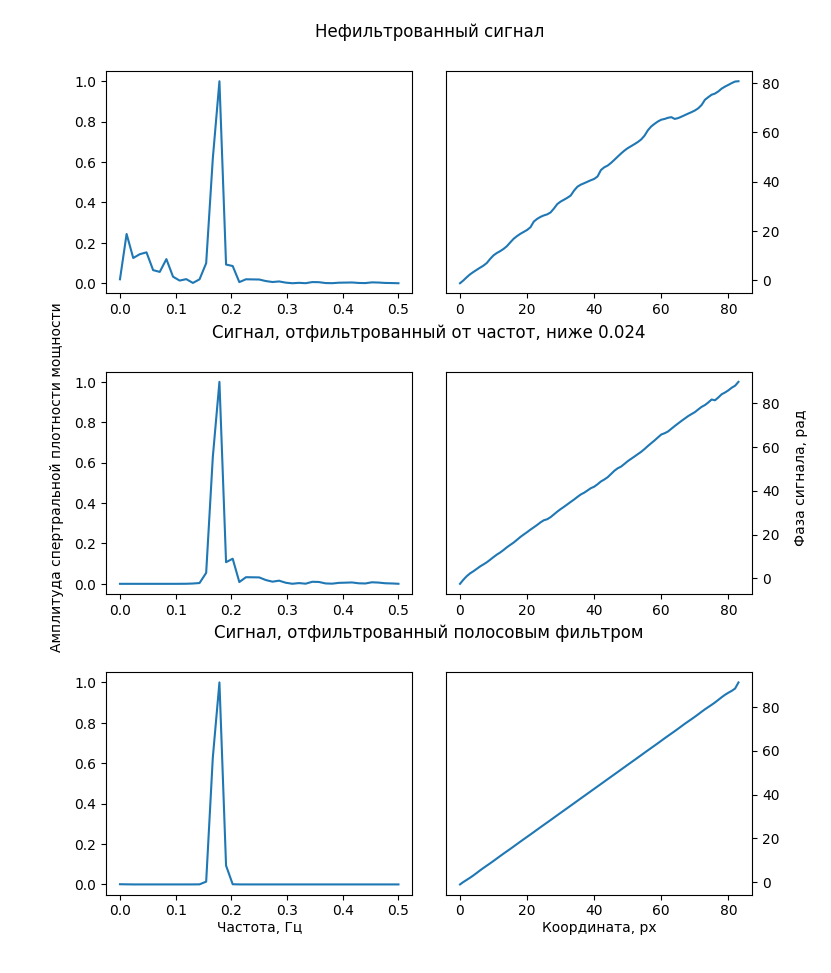

In [108]:
fig = plt.figure(figsize=(10, 12))

gs = gridspec.GridSpec(7, 4, width_ratios=[0.1, 1, 1, 0.1], height_ratios=[0.15,1,0.15,1,0.15,1,0.1]) 

# graphs
ax00 = fig.add_subplot(gs[1,1])
ax00.plot(f, p_den/np.max(p_den))
ax01 = fig.add_subplot(gs[1,2])
ax01.yaxis.tick_right()
ax01.plot(x, ph)

ax00 = fig.add_subplot(gs[3,1])
ax00.plot(fh, p_denh/np.max(p_denh))
ax01 = fig.add_subplot(gs[3,2])
ax01.yaxis.tick_right()
ax01.plot(x, ph_h)

ax00 = fig.add_subplot(gs[5,1])
ax00.plot(fw, p_denw/np.max(p_denw))
ax01 = fig.add_subplot(gs[5,2])
ax01.yaxis.tick_right()
ax01.plot(x, ph_w)

# axis x under the plots
axly1 = fig.add_subplot(gs[:,0], frameon=False)
axly1.tick_params(labelcolor='none', left=False, bottom=False)
axly1.text(0.5, 0.5, 'Амплитуда спертральной плотности мощности', rotation='vertical', ha='center', va='center', transform=axly1.transAxes)

axly2 = fig.add_subplot(gs[:,3], frameon=False)
axly2.tick_params(labelcolor='none', left=False, bottom=False)
axly2.text(0.5, 0.5, 'Фаза сигнала, рад', rotation='vertical', ha='center', va='center', transform=axly2.transAxes)

# axes y on the sides
axlx1 = fig.add_subplot(gs[6,1], frameon=False)
axlx1.tick_params(labelcolor='none', left=False, bottom=False)
axlx1.text(0.5, 0.5, 'Частота, Гц', ha='center', va='center', transform=axlx1.transAxes)

axlx2 = fig.add_subplot(gs[6,2], frameon=False)
axlx2.tick_params(labelcolor='none', left=False, bottom=False)
axlx2.text(0.5, 0.5, 'Координата, px', ha='center', va='center', transform=axlx2.transAxes)


# graph titles
axt1 = fig.add_subplot(gs[0,1:3], frameon=False)
axt1.tick_params(labelcolor='none', left=False, bottom=False)
axt1.text(0.5, 0.5, 'Нефильтрованный сигнал', fontsize=12, ha='center', va='center', transform=axt1.transAxes)

axt2 = fig.add_subplot(gs[2,1:3], frameon=False)
axt2.tick_params(labelcolor='none', left=False, bottom=False)
axt2.text(0.5, 0.5, f'Сигнал, отфильтрованный от частот, ниже {f_cut/5*8}', 
          ha='center', va='center', fontsize=12, transform=axt2.transAxes)

axt3 = fig.add_subplot(gs[4,1:3], frameon=False)
axt3.tick_params(labelcolor='none', left=False, bottom=False)
axt3.text(0.5, 0.5, f'Cигнал, отфильтрованный полосовым фильтром', 
          ha='center', va='center', fontsize=12, transform=axt3.transAxes)


plt.savefig('specDen_phase.jpg', dpi=120)
plt.show()

## Cosinus interpolation  method demonstration

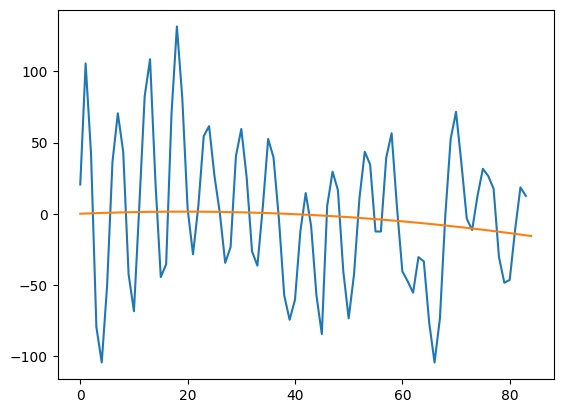

In [110]:
fringe.get_frq_cos()
fringe.plot(show_cos=True)

1.0942313043288465
[ 2.21880481e-01 -5.40355699e-03  5.20080754e+01  3.83802524e-01
  1.09423130e+00]


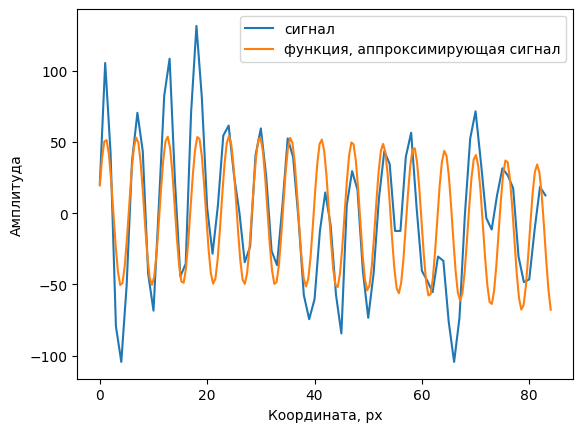

In [138]:
nl = fringe.count_peaks_of_autocorr()
w0 = 2*np.pi*nl/fringe.sig_len
amp = np.mean(np.abs(fringe.sig))
init = [0,0,amp,0,w0]

fringe.get_frq_cos(init_guess=init)
#fringe.plot(show_cos=True)


print(fringe.frq_cos)
print(fringe.popt_cos)

x = np.linspace(0,fringe.sig_len,200)

plt.figure()

plt.plot(fringe.sig)
plt.plot(x, fringe.func(x, *fringe.popt_cos))

plt.xlabel("Координата, px")
plt.ylabel("Амплитуда")
labels = ["сигнал","функция, аппроксимирующая сигнал"]
plt.legend(labels)

plt.savefig('sin_approx.jpg')
plt.show()